# 13.워드 클라우드 만들기
- 인터넷에서 좋은 글(연설문, 혹은 기사, 책 내용 등)을 찾아, txt로 저장하고 읽어와 워드 클라우드 만들어 보기

## 13.1.워드클라우드(wordcloud)란?
> 단어나 문장에서 자주 등장하는 단어들을, 글자 크기로 표현한 그림

- 단어가 많이 나올수록 크고 굵게 보임
- 단어가 적게 나올수록 작고 연하게 보임
- https://github.com/amueller/word_cloud

## 13.2.현실 예시
- 뉴스 기사 분석: 자주 나오는 단어를 시각화해서 핵심 키워드 파악
- 인터뷰나 리뷰 분석: 사람들이 어떤 단어를 많이 썼는지 쉽게 확인
- 설문조사 의견 분석: 자유답변을 시각화하여 트렌드 보기
- SNS 분석: 트위터, 블로그 글에서 자주 나오는 단어 파악

## 13.3.워드 클라우드 만드는 순서

1) 텍스트파일로 저장하기

    - 읽을 파일을 만듭니다.
    - 여기서는 수동으로 어디선가 가져오겠지만,
    - 나중에는 크롤링을 통해서 웹에서 가져올 수도 있습니다.
    
    
2) 텍스트 전처리

    - 파일을 읽어서 split() 메소드를 사용해 단어 단위로 쪼갭니다.
    - 단어별 빈도수를 계산하여 딕셔너리 형태로 저장합니다.
    - 분석에 의미가 없는 조사들은 제거합니다.
    
3) 워드 클라우드 그리기

    -  wordcloud 라이브러리를 설치한 후 불러옵니다.
    - 워드 클라우드를 그립니다.

**1) 텍스트 파일로 저장하기**

**2) 텍스트 전처리**
- 우선 파일을 읽어와 내용을 확인한다.
- 한글 파일을 읽어올 때 인코딩 오류가 발생하면 encoding='CP949'로 지정한다. 또는, encoding='UTF-8'로 지정한다.

In [2]:
f = open('/content/인연.txt', 'r', encoding='UTF-8')
text = f.read()
f.close()

text[:100]

'지난 사월 춘천에 가려고 하다가 못 가고 말았다. 나는 성심여자대학에 가보고\n싶었다. 그 학교에 어느 가을 학기, 매주 한 번씩 출강한 일이 있다. 힘드는 출강을 한\n학기 하게 된'

- split() 메소드를 사용해 단어 단위로 잘라 리스트 형태로 만든다.

In [5]:
wordlist = []


# 한글자, 마침표가 있는 단어 제거
for x in text.split():
    if '.' in x:
        pass
    elif len(x) == 1:
        pass
    else:
        wordlist.append(x)

wordlist[:10]

['지난', '사월', '춘천에', '가려고', '하다가', '가고', '나는', '성심여자대학에', '가보고', '학교에']

- 단어별 빈도수를 계산하여 딕셔너리로 저장한다.

In [9]:
# 중복 단어 제거
word_clean = set(wordlist)

wordCount = {}

for w in word_clean:
    wordCount[w] = wordlist.count(w)


In [23]:
# 불용어 제거(조사 제거)
stop_words = ['그리고', '있는', '이런', '그는', '아니', '같은', '내가', '나는', '하고', '나를']

# 제외하기
for w in stop_words:
    if w in wordCount:
        del wordCount[w]

In [24]:
wordCount

{'데도': 1,
 '번역': 1,
 '시바꾸': 1,
 '가을': 2,
 '가벼운': 1,
 '이쁜': 1,
 '마주친': 1,
 '것이': 1,
 '우리는': 1,
 '이야기한': 1,
 '어느덧': 1,
 '이름을': 1,
 '쪽으로': 1,
 '않은': 2,
 '나의': 1,
 '떠나던': 1,
 '되던': 1,
 '"쉘부르의': 1,
 '대한': 1,
 '국민학교': 1,
 '전문|작성자': 1,
 '몇번씩': 1,
 '아름다울': 1,
 '말대로': 1,
 '맞추고,': 1,
 '가보고': 1,
 '이튿날': 1,
 '교육가': 1,
 '있다가,': 1,
 '만나게': 1,
 '스치고': 1,
 '년이': 4,
 '"아,': 1,
 '웃는': 1,
 '피어': 1,
 '아이를': 1,
 '피천득': 1,
 '처음': 2,
 '서생도': 1,
 '기억하고': 1,
 '일생을': 1,
 '그냥': 1,
 '백합같이': 1,
 '그동안': 2,
 '돼서': 1,
 '꽃병에': 1,
 '하였을': 1,
 '그날': 1,
 '[출처]': 1,
 '맥아더': 1,
 '목을': 1,
 '좋은': 1,
 '싶다고': 1,
 '교실에서': 1,
 '시로가네에': 1,
 '기뻐하는': 1,
 '들어간다고': 1,
 '유명한': 1,
 "'스위트피'를": 1,
 '성심': 3,
 '소개로': 1,
 '얼굴이': 1,
 '절을': 1,
 '보면': 1,
 '수필집': 1,
 '만났어야': 1,
 '오신': 1,
 '아버지': 1,
 '끼던': 1,
 '소학교': 1,
 '싱싱하여야': 1,
 '시내에': 1,
 '있게': 1,
 '만나고': 2,
 '기관으로': 1,
 '악수도': 1,
 '소양강': 1,
 '선생네는': 1,
 '잊으면서도': 1,
 "'스위트피'는": 1,
 '미국': 2,
 '말인가': 1,
 '갔던': 1,
 '가톨릭': 1,
 '"한': 1,
 '번씩': 1,
 '산보를': 1,
 '웃으면서': 1,
 '춘천에': 2,
 '되기도': 1,
 '나

**3) 워드 클라우드 그리기**
- wordcloud 패키지를 설치하고, 워드 클라우드를 그린다.

In [25]:
# %pip install wordcloud

In [26]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
from wordcloud import  WordCloud

# 해상도를 높이는 코드
%config InlineBackend.figure_format='retina'

# 워드클라우드 만들기
wordcloud = WordCloud(font_path='/content/NanumBarunGothic.ttf',
                      width=2000,
                      height=1000,
                      max_font_size=100,
                      background_color='white').generate_from_frequencies(wordCount)

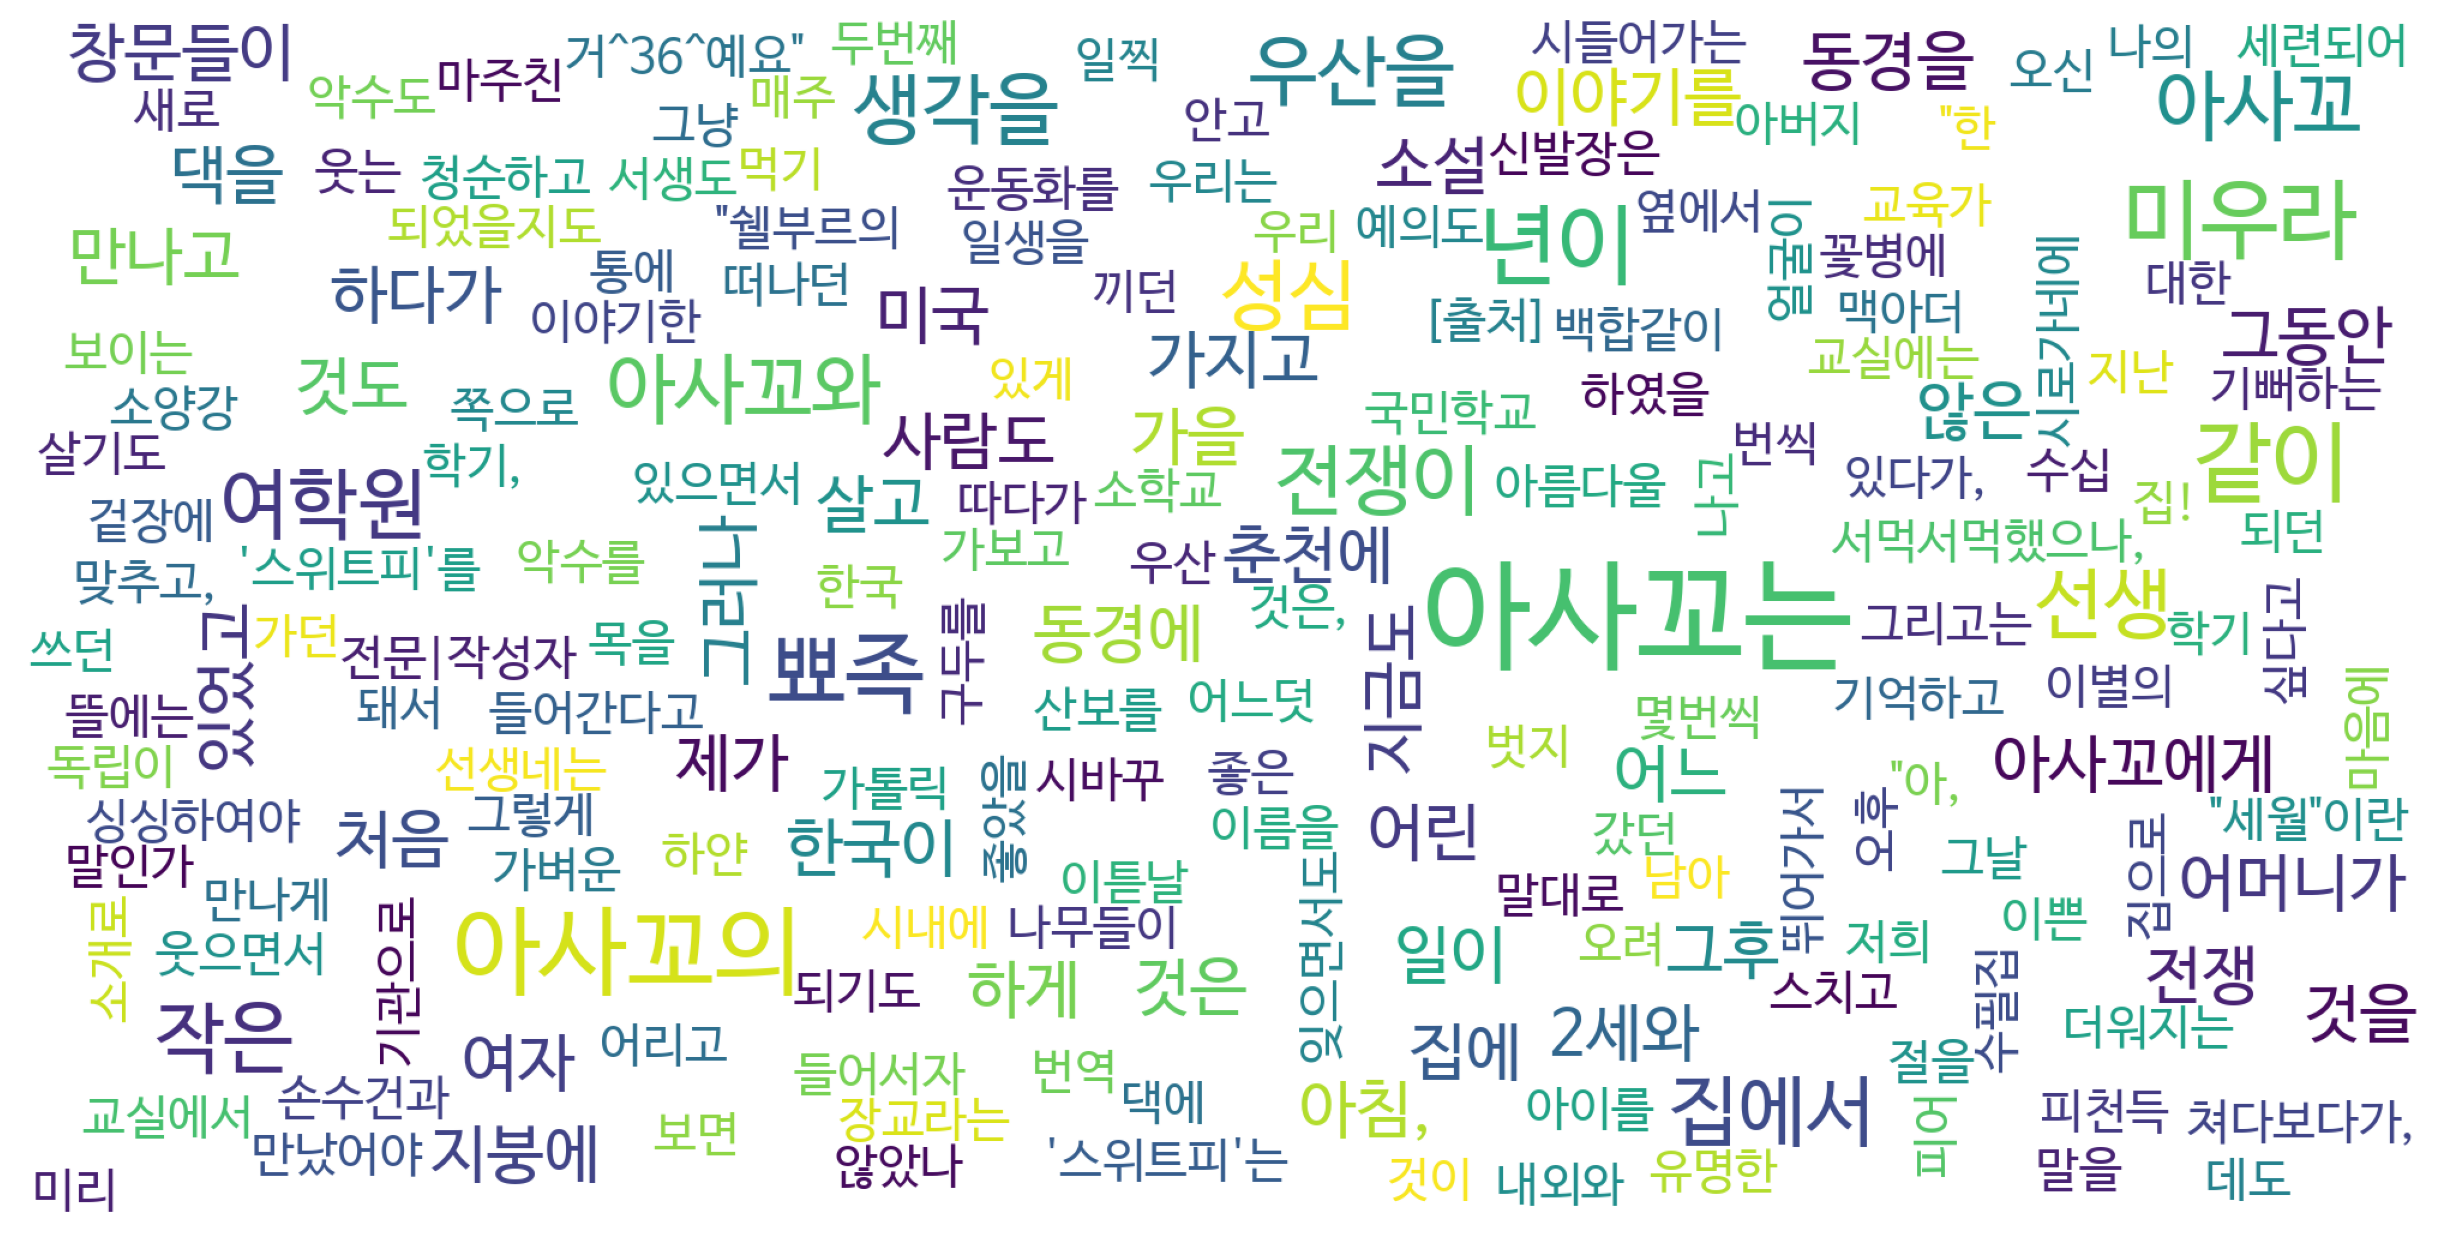

In [27]:
# 표시하기
plt.figure(figsize=(12,6))          # 그래프(figure) 크기 설정 (가로 12, 세로 6 인치)
plt.imshow(wordcloud)               # 워드클라우드 이미지를 화면에 표시
plt.axis('off')                     # x축, y축 눈금 제거 -> 깔끔하게 보이게 함
plt.tight_layout(pad=0)             # 그래프 여백 최소화(이미지가 꽉 차게)
plt.show()                          # 최종적으로 화면에 출력

- 이미지나 글씨 위에 워드클라우드 만들기

In [28]:
# 라이브러리 불러오기
import numpy as np
from PIL import  Image

# 이미지 불러오기
masking_image = np.array(Image.open('인연.jpg'))

# 워드 클라우드 만들기
wordcloud = WordCloud(font_path='/content/NanumBarunGothic.ttf',
                      width=2000,
                      height=1000,
                      mask = masking_image,
                      max_font_size=100,
                      background_color='white').generate_from_frequencies(wordCount)

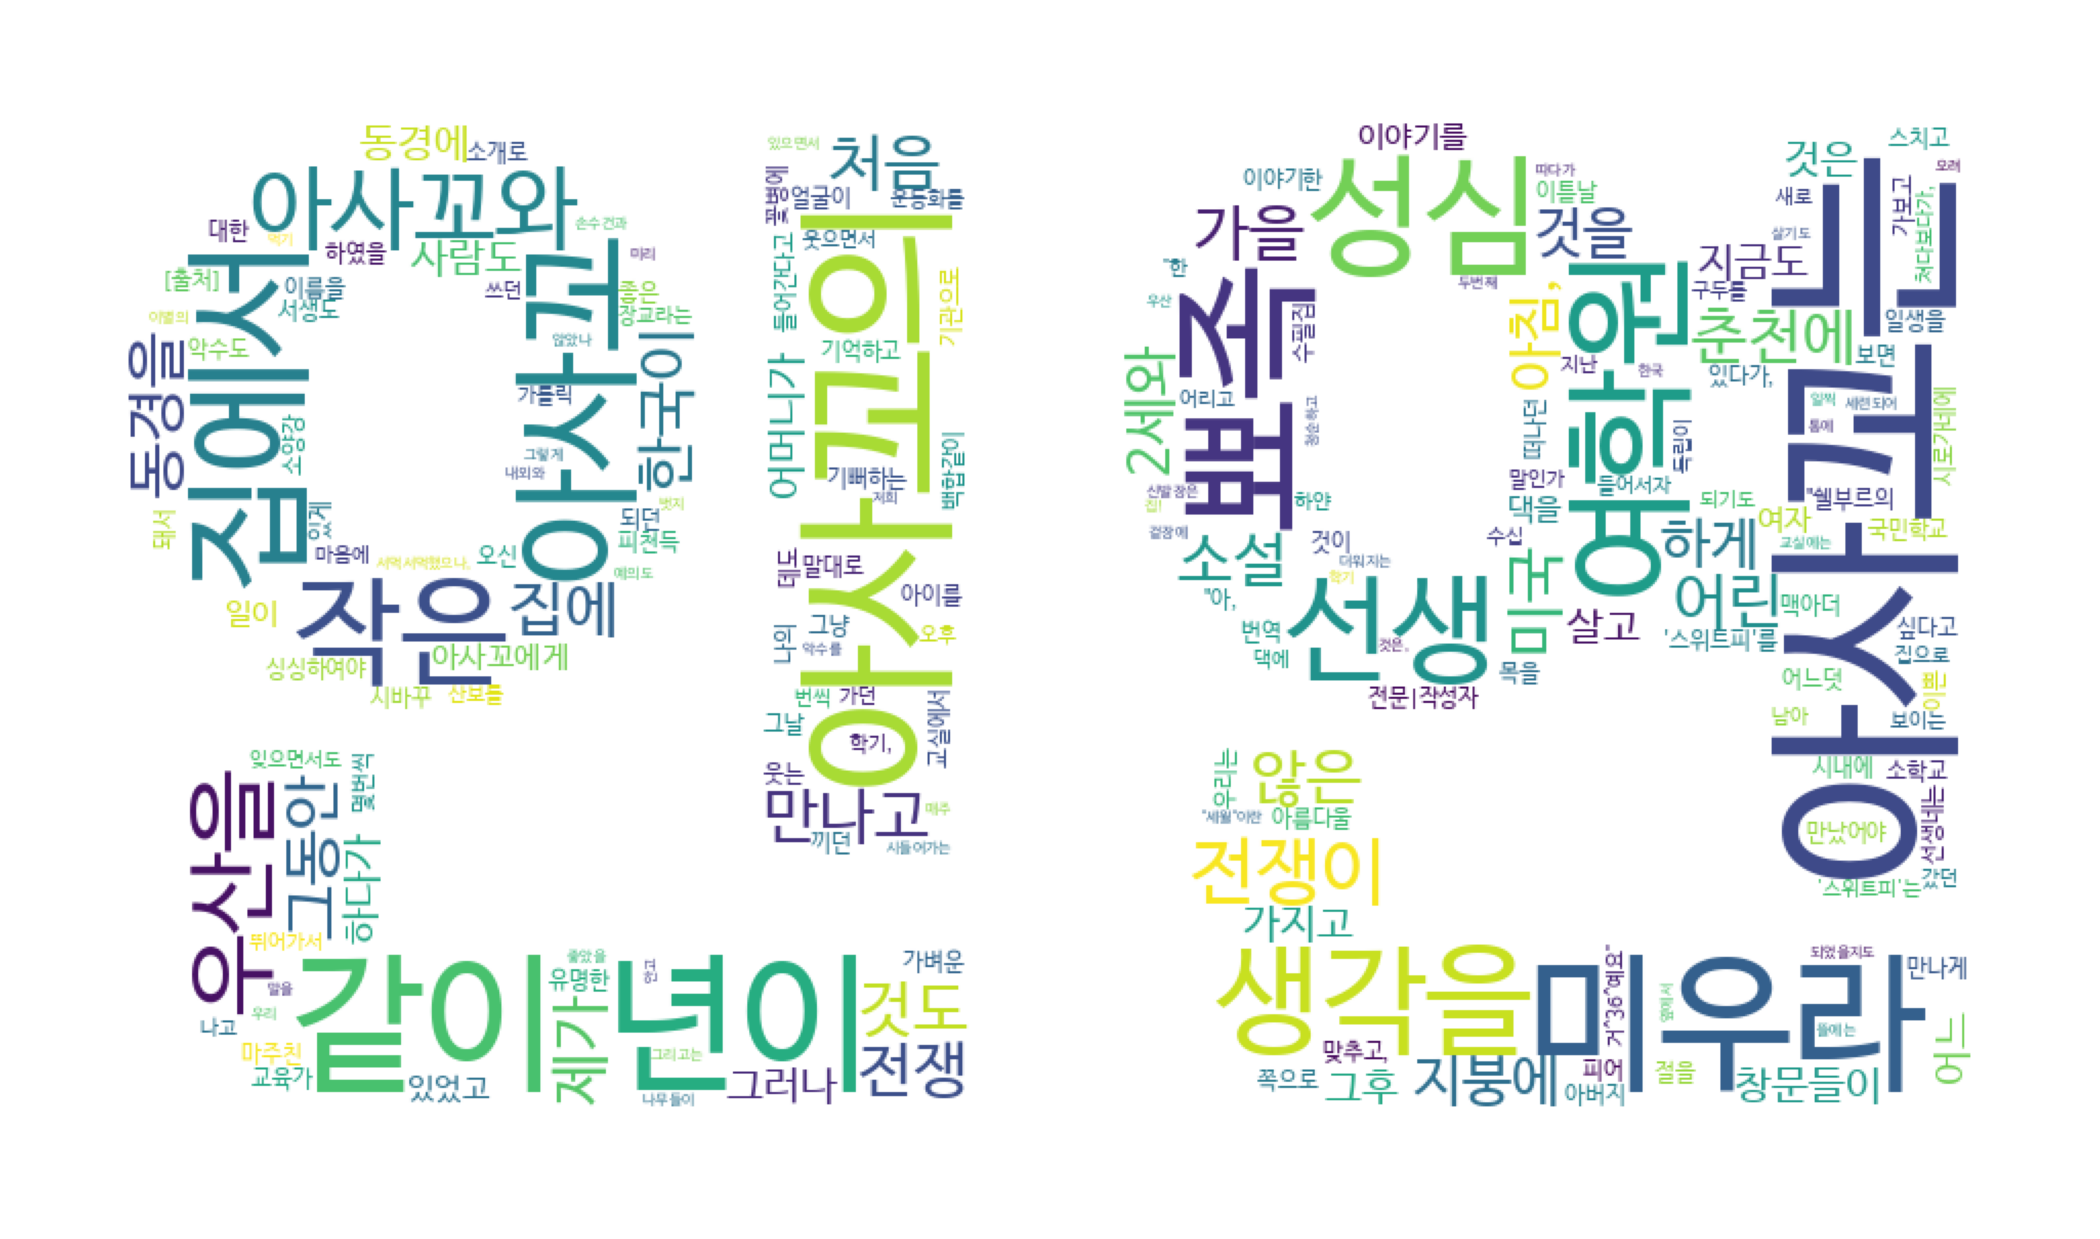

In [29]:
# 표시하기
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## 실습
1. 워드 클라우드 만들기
    - a. 데이터 수집 후 txt 파일을 만들어 업로드
    - b. 데이터 전처리
        - 심화
            - 불용어 사전
            - NLP 형태소 분석
            - 다양한 전처리
    - c. 워드 클라우드 만들기
2. '디스코드 -> 강의-실시간' 워드 클라우드 업로드
3. **11시 20분**까지 업로드 하기